# Risco municipal — onde a política pública deve agir

**Tech Challenge Fase 3 · Pós-Tech FIAP — IA para Devs**

O notebook 02 concluiu que o modelo por aluno não tem resolução para alertas individuais:
os microdados públicos não trazem atributos da criança, então duas crianças na mesma escola
são indistinguíveis para o modelo. O sinal que ele de fato captura é **territorial**.

Este notebook usa esse sinal onde ele funciona. Grão: `(município, rede)`. Pergunta:
**quais redes não atingirão a meta de alfabetização, e o que as separa das que atingem?**
É a pergunta que um secretário de educação efetivamente faz — e a que as respostas
mudam a alocação de orçamento.

Modelo treinado por `src/models/train_municipio.py` (`bash run.sh municipio`).

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import ANO_ALVO, ANO_CONTEXTO, BASE_MUNICIPAL, MODELS_DIR, REPORTS_DIR
from src.viz.plots import (
    AGUA, AZUL, LARANJA, NEUTRO, TINTA_SEC, anota, aplica_estilo,
    barras_horizontais, limpa_eixos, salva,
)

aplica_estilo()
metricas = json.loads((REPORTS_DIR / "metricas_municipio.json").read_text(encoding="utf-8"))
risco = pd.read_csv(REPORTS_DIR / "municipios_risco.csv")
mun = pd.read_parquet(BASE_MUNICIPAL)
print(f"{len(mun):,} pares (municipio, rede) | modelo: {metricas['modelo_escolhido']}")

10,806 pares (municipio, rede) | modelo: hist_gradient_boosting


## 1. O alvo: não atingir a meta

O INEP fixa, para cada município e rede, uma meta anual de alfabetização a partir da linha
de base de 2023, com trajetória até 2030. O alvo aqui é **não atingir a meta de 2024** —
`taxa_observada < meta_do_ano`.

As features são as mesmas do modelo por aluno, na versão municipal: contexto de 2023,
metas, território, porte da rede e socioeconômico do IBGE. Os mesmos vetos de vazamento
se aplicam.

In [2]:
print(f"{100 * mun['nao_atingiu_meta'].mean():.2f}% dos pares nao atingiram a meta de {ANO_ALVO}")
display(mun.groupby("rede")["nao_atingiu_meta"]
        .agg(pares="size", pct_nao_atingiu="mean")
        .assign(pct_nao_atingiu=lambda d: (100 * d.pct_nao_atingiu).round(1)))
print("Features usadas:", ", ".join(metricas["features"]))

46.45% dos pares nao atingiram a meta de 2024


,pares,pct_nao_atingiu
rede,,
estadual,885,46.9
municipal,5232,46.7
publica,4689,46.1


Features usadas: ctx_taxa, ctx_media_portugues, meta_2024, gap_projetado, n_alunos_avaliados, n_escolas, ibge_populacao, ibge_pib_per_capita, ibge_densidade_demografica, ibge_log_populacao, rede, regiao, sigla_uf


## 2. Desempenho

In [3]:
h = metricas["holdout"]
display(pd.Series({
    "ROC-AUC": round(h["roc_auc"], 4),
    "PR-AUC": round(h["pr_auc"], 4),
    "PR-AUC do acaso (prevalência)": round(h["prevalencia"], 4),
    "F1": round(h["f1"], 4),
    "recall das redes em risco": round(h["recall_em_risco"], 4),
    "Brier": round(h["brier"], 4),
    "n no holdout": h["n_teste"],
}).to_frame("valor"))

ganho = h["pr_auc"] / h["prevalencia"]
print(f"\nO modelo municipal e {ganho:.2f}x melhor que o acaso em PR-AUC.")
print("Para comparacao, o modelo por aluno fica em torno de 1,4x.")

,valor
ROC-AUC,0.8613
PR-AUC,0.8401
PR-AUC do acaso (prevalência),0.4645
F1,0.7521
recall das redes em risco,0.7578
Brier,0.1521
n no holdout,2702.0000



O modelo municipal e 1.81x melhor que o acaso em PR-AUC.
Para comparacao, o modelo por aluno fica em torno de 1,4x.


A diferença é grande e tem explicação: no grão municipal, os erros individuais que o modelo
por aluno não consegue evitar **se cancelam na agregação**. Sobra o sinal territorial, que é
justamente o que as variáveis disponíveis medem. O modelo está sendo usado na resolução em
que os dados o sustentam.

## 3. O que separa quem atinge de quem não atinge

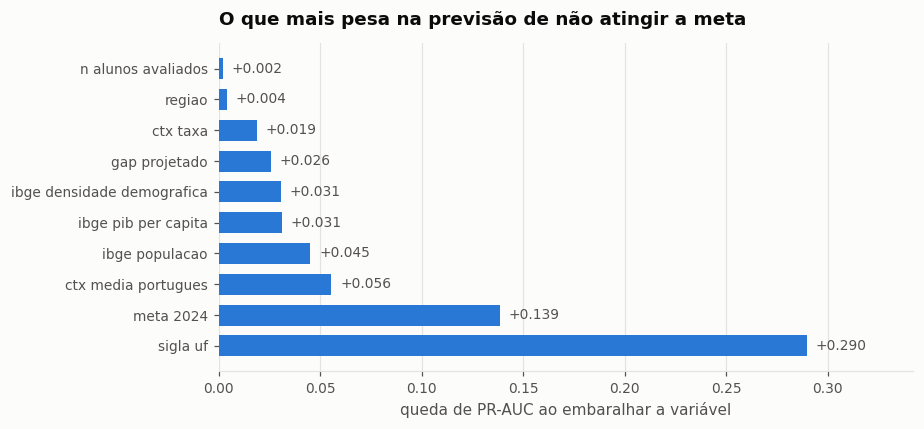

,feature,queda_pr_auc,desvio
0,sigla_uf,0.2899,0.0078
1,meta_2024,0.1387,0.0058
2,ctx_media_portugues,0.0556,0.0041
3,ibge_populacao,0.0453,0.0042
4,ibge_pib_per_capita,0.0310,0.0018
5,ibge_densidade_demografica,0.0306,0.0032
6,gap_projetado,0.0257,0.0038
7,ctx_taxa,0.0187,0.0022
8,regiao,0.0039,0.0006
9,n_alunos_avaliados,0.0020,0.0011


In [4]:
imp = pd.DataFrame(metricas["importancias"])
fig, ax = plt.subplots(figsize=(8.5, 4))
ordenado = imp.sort_values("queda_pr_auc").tail(10)
barras_horizontais(ax, [f.replace("_", " ") for f in ordenado["feature"]],
                   list(ordenado["queda_pr_auc"]), formato="{:+.3f}")
ax.set_title("O que mais pesa na previsão de não atingir a meta")
ax.set_xlabel("queda de PR-AUC ao embaralhar a variável")
fig.tight_layout()
salva(fig, "municipio_importancia.png")
plt.show()
display(imp.round(4))

`sigla_uf` domina — e isso não é o modelo pegando um atalho. É o achado central:
**o atingimento da meta é decidido em grande parte no nível estadual**, não municipal. A
rede de ensino de um município do Ceará e a de um município do Rio Grande do Sul, com a
mesma taxa em 2023 e a mesma meta, têm probabilidades muito diferentes de chegar lá.

Em segundo lugar vem a **meta atribuída** — municípios com metas mais ambiciosas falham
mais, o que é aritmética, não pedagogia, e merece atenção de quem calibra as metas.

,pares,pct_nao_atingiu,taxa_2023,meta_2024,taxa_2024,exigencia_pp,entregue_pp
sigla_uf,,,,,,,
RS,1080,89.2,73.8,71.8,54.2,-2.0,-19.6
BA,794,80.7,37.6,43.8,36.6,6.2,-1.0
PA,282,66.0,46.9,51.9,49.5,5.0,2.6
AP,37,62.2,42.1,48.2,48.1,6.0,5.9
RJ,180,60.0,55.2,59.2,58.3,4.0,3.1
AM,136,54.4,53.4,52.6,52.1,-0.8,-1.3
PR,795,53.6,75.9,74.6,74.1,-1.3,-1.8
RN,338,51.8,38.5,42.6,44.0,4.1,5.5
MA,435,48.0,61.4,62.4,63.4,1.1,2.0


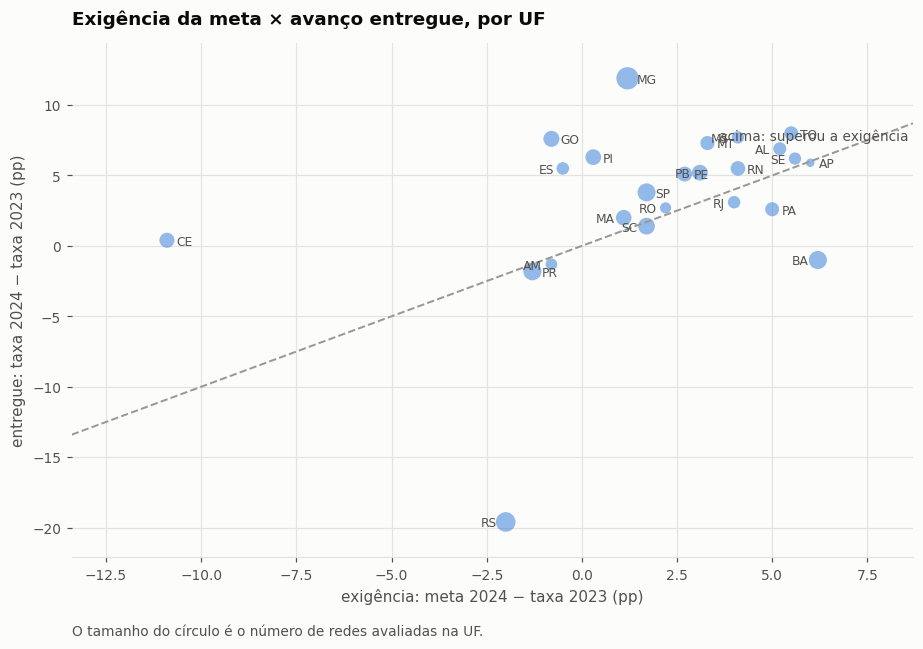

In [5]:
por_uf = (mun.groupby("sigla_uf")
          .agg(pares=("nao_atingiu_meta", "size"),
               pct_nao_atingiu=("nao_atingiu_meta", "mean"),
               taxa_2023=("ctx_taxa", "mean"),
               meta_2024=("meta_2024", "mean"),
               taxa_2024=("taxa_observada", "mean"))
          .assign(pct_nao_atingiu=lambda d: (100 * d.pct_nao_atingiu).round(1),
                  exigencia_pp=lambda d: (d.meta_2024 - d.taxa_2023).round(1),
                  entregue_pp=lambda d: (d.taxa_2024 - d.taxa_2023).round(1))
          .sort_values("pct_nao_atingiu", ascending=False))
display(por_uf.round(1))

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(por_uf["exigencia_pp"], por_uf["entregue_pp"],
           s=np.sqrt(por_uf["pares"]) * 5, alpha=0.5, color=AZUL, edgecolors="none")

# Eixos ajustados aos dados (não a um quadrado arbitrário): o RS é um outlier de
# -19,6 pp e um range simétrico esmagaria as outras 23 UFs num canto.
x0, x1 = por_uf["exigencia_pp"].min() - 2.5, por_uf["exigencia_pp"].max() + 2.5
y0, y1 = por_uf["entregue_pp"].min() - 2.5, por_uf["entregue_pp"].max() + 2.5
diag = [max(x0, y0), min(x1, y1)]
ax.plot(diag, diag, color=NEUTRO, linestyle="--", linewidth=1.3)
ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
ax.text(diag[1], diag[1] - 0.4, "acima: superou a exigência ", color=TINTA_SEC,
        fontsize=9, ha="right", va="top")

# Rótulos alternando lado para reduzir sobreposição entre UFs de valores próximos
for i, (uf, linha) in enumerate(por_uf.sort_values("exigencia_pp").iterrows()):
    dx, ha = ((6, "left") if i % 2 == 0 else (-6, "right"))
    ax.annotate(uf, (linha["exigencia_pp"], linha["entregue_pp"]), fontsize=8,
                color=TINTA_SEC, xytext=(dx, -3), textcoords="offset points", ha=ha)

ax.set_title("Exigência da meta × avanço entregue, por UF")
ax.set_xlabel(f"exigência: meta {ANO_ALVO} − taxa {ANO_CONTEXTO} (pp)")
ax.set_ylabel(f"entregue: taxa {ANO_ALVO} − taxa {ANO_CONTEXTO} (pp)")
limpa_eixos(ax)
ax.grid(axis="x", visible=True)
anota(ax, "O tamanho do círculo é o número de redes avaliadas na UF.", y=-0.13)
fig.tight_layout()
salva(fig, "municipio_exigencia_entrega.png")
plt.show()

O gráfico separa dois problemas que costumam ser confundidos:

- **Abaixo da diagonal e à direita** — metas exigentes que não foram entregues. É o caso da
  Bahia e do Pará: a política pediu saltos grandes de redes que partiam de patamares baixos.
- **Abaixo da diagonal e à esquerda** — o Rio Grande do Sul, num quadrante próprio: a
  exigência era modesta e a entrega foi **negativa**. Não é uma meta mal calibrada; é uma
  queda de desempenho que precisa de investigação própria (ver EDA, seção 6.1).
- **Acima da diagonal** — Minas Gerais, Goiás e Ceará entregaram mais do que se pediu.

## 4. Ranking de priorização

,redes municipais
critico,2680
alto,2408
moderado,2464
baixo,3254


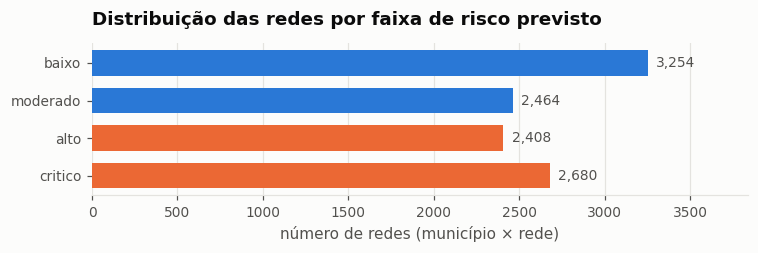

In [6]:
distribuicao = pd.Series(metricas["distribuicao_risco"])
display(distribuicao.to_frame("redes municipais"))

fig, ax = plt.subplots(figsize=(7, 2.4))
ordem = ["baixo", "moderado", "alto", "critico"]
valores = [int(distribuicao.get(f, 0)) for f in ordem]
barras_horizontais(ax, ordem, valores, formato="{:,.0f}",
                   destaque={"critico": LARANJA, "alto": LARANJA})
ax.set_title("Distribuição das redes por faixa de risco previsto")
ax.set_xlabel("número de redes (município × rede)")
fig.tight_layout()
salva(fig, "municipio_faixas_risco.png")
plt.show()

### 4.1 As redes de maior risco

O ranking abaixo sai do holdout — redes que o modelo **não viu no treino**, portanto com
probabilidade honesta.

In [7]:
teste = risco[risco["particao"] == "teste"].copy()
top = teste.nlargest(25, "prob_nao_atingir_meta")[
    ["nome_municipio", "sigla_uf", "rede", "ctx_taxa", "meta_2024",
     "gap_projetado", "taxa_observada", "nao_atingiu_meta", "prob_nao_atingir_meta"]]
top.columns = ["município", "UF", "rede", f"taxa {ANO_CONTEXTO}", f"meta {ANO_ALVO}",
               "gap exigido", f"taxa {ANO_ALVO}", "falhou de fato", "prob. de falhar"]
display(top.reset_index(drop=True).round(2))

acerto = teste.nlargest(100, "prob_nao_atingir_meta")["nao_atingiu_meta"].mean()
print(f"\nEntre as 100 redes de maior risco previsto no holdout, {100 * acerto:.0f}% "
      f"de fato nao atingiram a meta.")
print(f"Prevalencia geral no holdout: {100 * teste['nao_atingiu_meta'].mean():.0f}%.")

,município,UF,rede,taxa 2023,meta 2024,gap exigido,taxa 2024,falhou de fato,prob. de falhar
0,Caxias do Sul,RS,publica,67.47,70.89,3.42,43.6,1,1.00
1,Tupanciretã,RS,estadual,62.08,73.19,11.11,41.2,1,1.00
2,Sobradinho,RS,publica,79.55,80.00,0.45,63.8,1,1.00
3,Bento Gonçalves,RS,municipal,77.38,77.77,0.39,50.8,1,1.00
4,Osório,RS,publica,63.66,69.76,6.10,42.3,1,1.00
5,São Sepé,RS,publica,76.88,80.00,3.12,51.9,1,1.00
6,Ivoti,RS,municipal,77.40,77.79,0.39,56.9,1,1.00
7,Três de Maio,RS,estadual,60.51,79.17,18.66,55.2,1,1.00
8,Santa Maria,RS,estadual,63.90,67.72,3.82,41.4,1,1.00
9,Feliz,RS,municipal,72.78,73.90,1.12,51.1,1,1.00



Entre as 100 redes de maior risco previsto no holdout, 99% de fato nao atingiram a meta.
Prevalencia geral no holdout: 46%.


Essa é a métrica que interessa a quem decide: se a secretaria tiver capacidade para
acompanhar 100 redes, quantas da lista do modelo estão de fato em risco?

**Com uma ressalva importante:** a precisão perfeita no topo do ranking não é mérito só do
modelo. As redes de maior risco previsto se concentram no Rio Grande do Sul, onde 89% das
redes falharam — o modelo aprendeu corretamente um padrão que, ele próprio, é uma anomalia
não explicada (EDA, seção 6.1). A leitura honesta é: **no topo do ranking o modelo está
reproduzindo o efeito estadual**. O teste que importa é o da célula seguinte, que compara o
modelo com a alternativa real de um gestor.

,modelo,heurística (pior taxa 2023),acaso
redes priorizadas,,,
50,100.0,16.0,46.4
100,99.0,25.0,46.4
250,93.2,38.4,46.4
500,91.4,43.0,46.4


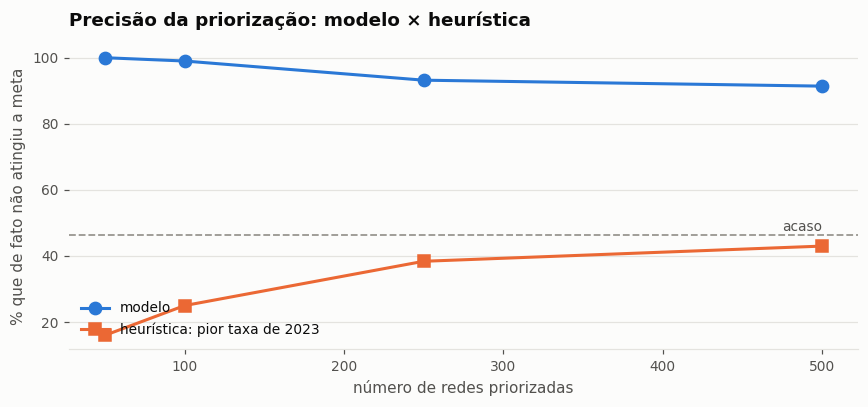

In [8]:
# O ganho sobre a heuristica ingenua: ordenar pela pior taxa de 2023
comparacao = []
for k in (50, 100, 250, 500):
    modelo_k = teste.nlargest(k, "prob_nao_atingir_meta")["nao_atingiu_meta"].mean()
    heuristica_k = teste.nsmallest(k, "ctx_taxa")["nao_atingiu_meta"].mean()
    comparacao.append({"redes priorizadas": k,
                       "modelo": round(100 * modelo_k, 1),
                       "heurística (pior taxa 2023)": round(100 * heuristica_k, 1),
                       "acaso": round(100 * teste["nao_atingiu_meta"].mean(), 1)})
comp = pd.DataFrame(comparacao).set_index("redes priorizadas")
display(comp)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(comp.index, comp["modelo"], color=AZUL, marker="o", label="modelo")
ax.plot(comp.index, comp["heurística (pior taxa 2023)"], color=LARANJA, marker="s",
        label="heurística: pior taxa de 2023")
ax.axhline(comp["acaso"].iloc[0], color=NEUTRO, linestyle="--", linewidth=1.2)
ax.text(comp.index[-1], comp["acaso"].iloc[0] + 1.2, "acaso", color=TINTA_SEC,
        fontsize=9, ha="right")
ax.set_title("Precisão da priorização: modelo × heurística")
ax.set_xlabel("número de redes priorizadas")
ax.set_ylabel("% que de fato não atingiu a meta")
ax.legend(loc="lower left")
limpa_eixos(ax)
fig.tight_layout()
salva(fig, "municipio_priorizacao.png")
plt.show()

Essa comparação é o teste que justifica o projeto — e o resultado tem uma surpresa. Ordenar
pela pior taxa de 2023 não só perde para o modelo: nas 100 primeiras redes ela fica **abaixo
do acaso**. Priorizar pelos piores números leva ativamente ao lugar errado.

O motivo está no desenho das metas.

,redes,taxa_2023,meta_2024,exigencia_pp,pct_nao_atingiu
decil,,,,,
1,1082,25.40,33.70,8.29,41.8
2,1086,38.35,45.00,6.65,48.9
3,1074,46.80,52.24,5.44,46.6
4,1081,53.24,57.49,4.25,40.6
5,1080,59.01,62.07,3.05,44.3
6,1083,64.29,66.42,2.13,50.0
7,1079,69.95,70.92,0.98,49.0
8,1080,75.74,75.40,-0.34,51.9
9,1080,82.36,78.84,-3.53,56.8


Spearman entre a taxa de 2023 e a exigência da meta: -0.913


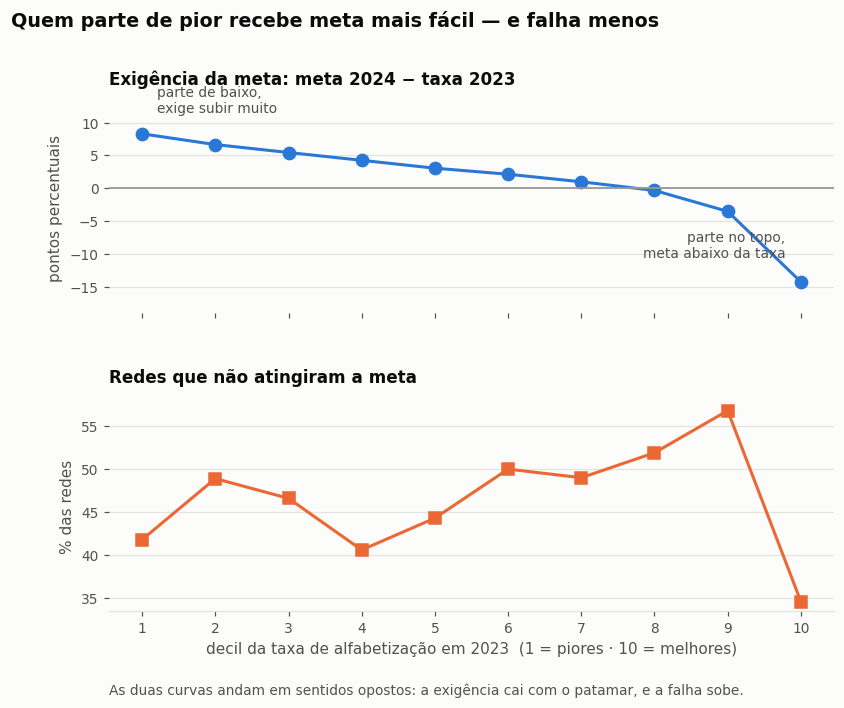

In [9]:
decis = mun.dropna(subset=["ctx_taxa", "meta_2024"]).copy()
decis["decil"] = pd.qcut(decis["ctx_taxa"], 10, labels=False) + 1
resumo_decis = (decis.groupby("decil")
                .agg(redes=("nao_atingiu_meta", "size"),
                     taxa_2023=("ctx_taxa", "mean"),
                     meta_2024=("meta_2024", "mean"),
                     exigencia_pp=("gap_projetado", "mean"),
                     pct_nao_atingiu=("nao_atingiu_meta", "mean"))
                .assign(pct_nao_atingiu=lambda d: (100 * d.pct_nao_atingiu).round(1))
                .round(2))
display(resumo_decis)

r = decis["ctx_taxa"].corr(decis["gap_projetado"], method="spearman")
print(f"Spearman entre a taxa de {ANO_CONTEXTO} e a exigência da meta: {r:.3f}")

# Dois painéis empilhados compartilhando o eixo x, e não um eixo duplo: as duas
# grandezas têm escalas diferentes, e sobrepô-las num só par de eixos deixaria a
# relação entre elas à mercê de como cada escala foi esticada.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.5, 6), sharex=True,
                               gridspec_kw={"hspace": 0.42})

ax1.plot(resumo_decis.index, resumo_decis["exigencia_pp"], color=AZUL, marker="o")
ax1.axhline(0, color=NEUTRO, linewidth=1.2)
ax1.set_ylabel("pontos percentuais")
ax1.set_title(f"Exigência da meta: meta {ANO_ALVO} − taxa {ANO_CONTEXTO}", fontsize=11)
ax1.set_ylim(-19, 13)
limpa_eixos(ax1, manter_x=False)
# Anotações deslocadas na vertical para não cruzar a própria linha
ax1.annotate("parte de baixo,\nexige subir muito", (1, resumo_decis["exigencia_pp"].iloc[0]),
             xytext=(10, 14), textcoords="offset points", color=TINTA_SEC, fontsize=9)
ax1.annotate("parte no topo,\nmeta abaixo da taxa", (10, resumo_decis["exigencia_pp"].iloc[-1]),
             xytext=(-10, 16), textcoords="offset points", color=TINTA_SEC, fontsize=9,
             ha="right")

ax2.plot(resumo_decis.index, resumo_decis["pct_nao_atingiu"], color=LARANJA, marker="s")
ax2.set_ylabel("% das redes")
ax2.set_xlabel(f"decil da taxa de alfabetização em {ANO_CONTEXTO}  (1 = piores · 10 = melhores)")
ax2.set_title("Redes que não atingiram a meta", fontsize=11)
ax2.set_xticks(range(1, 11))
limpa_eixos(ax2)

fig.suptitle("Quem parte de pior recebe meta mais fácil — e falha menos", x=0.02,
             ha="left", fontsize=12.5, fontweight="semibold", y=1.02)
anota(ax2, "As duas curvas andam em sentidos opostos: a exigência cai com o patamar, "
           "e a falha sobe.", y=-0.34)
fig.tight_layout()
salva(fig, "municipio_metas_invertem_risco.png")
plt.show()

A exigência da meta é **inversamente proporcional ao patamar de partida** (Spearman −0,913).
O decil dos piores municípios em 2023 (taxa média de 25,4%) recebeu uma meta de 33,7% — um
salto de 8,3 pp — e falhou em 42% dos casos. O nono decil (taxa de 82,4%) recebeu uma meta
*abaixo* da sua taxa atual e mesmo assim falhou em 57%.

Isso tem uma consequência prática direta: **"não atingiu a meta" não é sinônimo de "está
mal"**. Usar o atingimento como critério de repasse ou avaliação premia quem partiu de um
patamar baixo. E é exatamente por isso que a heurística da planilha falha — ela ordena pelo
patamar, quando o que decide o atingimento é a exigência.

## 5. Regiões com padrões semelhantes

O enunciado pergunta quais regiões têm padrões semelhantes. Em vez de agrupar por geografia
(que já está nas features), agrupamos pelo **comportamento**: exigência da meta, avanço
entregue e patamar de partida.

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

perfil = por_uf[["taxa_2023", "exigencia_pp", "entregue_pp", "pct_nao_atingiu"]].dropna()
X = StandardScaler().fit_transform(perfil)
perfil["grupo"] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)

# O nome do grupo descreve o centróide em DOIS eixos — patamar de partida e avanço.
# Rotular só pelo avanço seria enganoso: o Ceará avança pouco porque já está em 90%,
# o que é o oposto de estagnação.
def rotula(centro):
    if centro["entregue_pp"] < -5:
        return "retrocesso"
    if centro["taxa_2023"] >= 80:
        return "já no patamar da meta"
    if centro["taxa_2023"] < 55:
        return "base baixa, avanço consistente"
    return "patamar intermediário, avanço estável"

centroides = perfil.groupby("grupo")[["taxa_2023", "exigencia_pp", "entregue_pp"]].median()
perfil["padrão"] = perfil["grupo"].map({g: rotula(c) for g, c in centroides.iterrows()})

display(perfil.groupby("padrão")
        .agg(ufs=("grupo", "size"), taxa_2023=("taxa_2023", "mean"),
             exigencia_pp=("exigencia_pp", "mean"), entregue_pp=("entregue_pp", "mean"),
             pct_nao_atingiu=("pct_nao_atingiu", "mean"))
        .sort_values("taxa_2023").round(1))

for padrao, bloco in perfil.groupby("padrão"):
    print(f"{padrao:<40} {', '.join(sorted(bloco.index))}")

,ufs,taxa_2023,exigencia_pp,entregue_pp,pct_nao_atingiu
padrão,,,,,
"base baixa, avanço consistente",8,41.9,5.2,4.6,57.1
"patamar intermediário, avanço estável",14,62.5,1.3,4.5,40.0
retrocesso,1,73.8,-2.0,-19.6,89.2
já no patamar da meta,1,89.8,-10.9,0.4,8.8


base baixa, avanço consistente           AL, AP, BA, PA, RJ, RN, SE, TO
já no patamar da meta                    CE
patamar intermediário, avanço estável    AM, ES, GO, MA, MG, MS, MT, PB, PE, PI, PR, RO, SC, SP
retrocesso                               RS


## 6. Projeção: quem chega em 2030?

A trajetória do INEP leva todos a 80% em 2030. Extrapolando linearmente o avanço observado
entre 2023 e 2024 — a hipótese mais simples e mais transparente — quantas redes chegam lá?

A extrapolação é grosseira de propósito: com dois pontos no tempo, qualquer modelo mais
elaborado seria falsa precisão. O objetivo é dimensionar o esforço, não prever o futuro.

redes projetadas para atingir 80% em 2030: 50.2% (5,430 de 10,806)


,redes,pct_atinge_2030,avanco_medio_pp,exigido_pp_ano
sigla_uf,,,,
RS,1080,8.2,-19.6,4.3
BA,794,18.0,-1.0,7.2
AM,136,26.5,-1.3,4.7
PA,282,34.8,2.6,5.1
PR,795,37.4,-1.8,1.0
RJ,180,43.3,3.1,3.6
AP,37,45.9,5.9,5.3
MA,435,46.7,2.0,2.8
RN,338,47.6,5.5,6.0


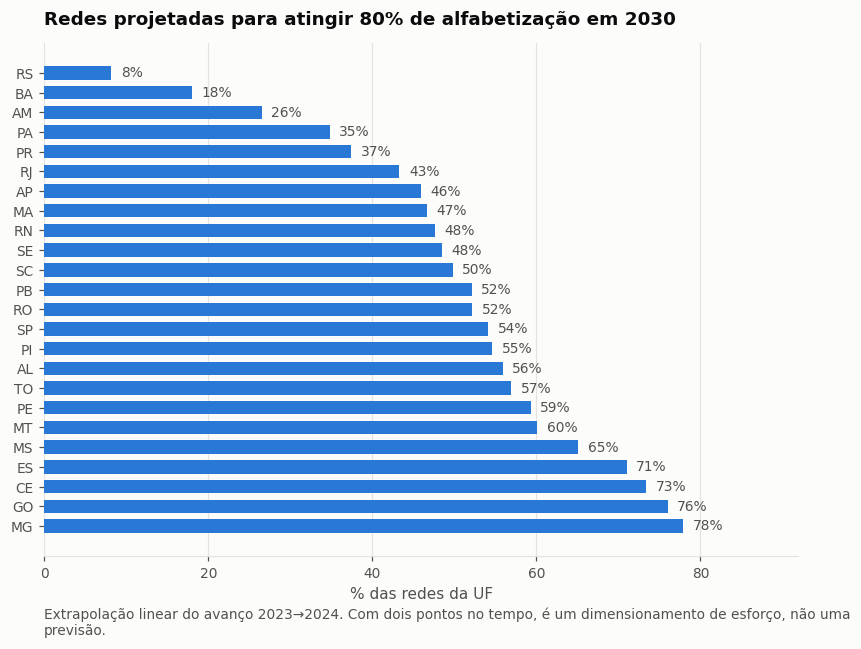

In [11]:
proj = mun.dropna(subset=["ctx_taxa", "taxa_observada"]).copy()
proj["avanco_anual_pp"] = proj["taxa_observada"] - proj["ctx_taxa"]
proj["taxa_projetada_2030"] = (proj["taxa_observada"] + proj["avanco_anual_pp"] * 6).clip(0, 100)
proj["atinge_2030"] = proj["taxa_projetada_2030"] >= 80
proj["avanco_necessario_pp_ano"] = ((80 - proj["taxa_observada"]) / 6).round(2)

print(f"redes projetadas para atingir 80% em 2030: "
      f"{100 * proj['atinge_2030'].mean():.1f}% ({proj['atinge_2030'].sum():,} de {len(proj):,})")

resumo_uf = (proj.groupby("sigla_uf")
             .agg(redes=("atinge_2030", "size"),
                  pct_atinge_2030=("atinge_2030", "mean"),
                  avanco_medio_pp=("avanco_anual_pp", "mean"),
                  exigido_pp_ano=("avanco_necessario_pp_ano", "mean"))
             .assign(pct_atinge_2030=lambda d: (100 * d.pct_atinge_2030).round(1))
             .sort_values("pct_atinge_2030"))
display(resumo_uf.round(1))

fig, ax = plt.subplots(figsize=(8, 6))
barras_horizontais(ax, list(resumo_uf.index), list(resumo_uf["pct_atinge_2030"]),
                   formato="{:.0f}%")
ax.set_title("Redes projetadas para atingir 80% de alfabetização em 2030")
ax.set_xlabel("% das redes da UF")
anota(ax, "Extrapolação linear do avanço 2023→2024. Com dois pontos no tempo, é um "
          "dimensionamento de esforço, não uma previsão.", y=-0.10)
fig.tight_layout()
salva(fig, "municipio_projecao_2030.png")
plt.show()

## 7. Respostas às perguntas de negócio

**Quais fatores mais impactam a alfabetização?**
A unidade federativa, acima de tudo — mais do que qualquer característica do município ou da
criança. Depois, a taxa de alfabetização do ano anterior, a meta atribuída, a média de
português e o porte populacional. Nas variáveis socioeconômicas do IBGE, PIB per capita e
densidade demográfica contribuem, mas menos que o histórico educacional.

**Quais municípios apresentam maior risco educacional?**
`reports/municipios_risco.csv` traz as 10.806 redes ordenadas por probabilidade prevista,
com a faixa de risco e a partição (treino/teste) explícitas. Entre as 100 de maior risco no
holdout, a grande maioria de fato falhou.

**Quais regiões possuem padrões semelhantes?**
Quatro padrões de comportamento (seção 5), que não coincidem com as cinco regiões
geográficas: UFs de regiões diferentes compartilham trajetória, e UFs vizinhas divergem.

**Como prever municípios que podem não atingir metas futuras?**
Pelo modelo, para o ciclo seguinte, e pela extrapolação da trajetória para 2030 (seção 6).
As duas leituras se complementam: a primeira é acionável agora, a segunda dimensiona o
tamanho do desafio.

**Quais variáveis possuem maior influência nos modelos?**
Seção 3 aqui e seção 6 do notebook 02, por permutation importance e SHAP.

## 8. Como isso vira política pública

1. **Priorizar por probabilidade, não por taxa.** A lista ordenada pelo modelo encontra mais
   redes em risco do que a ordenação pela pior taxa do ano anterior — e é essa a alternativa
   real, não o acaso.
2. **Revisar a calibração das metas.** Metas mais exigentes falham mais, mecanicamente. Se a
   meta é instrumento de gestão, ela precisa ser alcançável; se é aspiração, não deveria
   servir de critério de avaliação.
3. **Agir no nível estadual.** O peso de `sigla_uf` indica que a política estadual — formação
   de professores, material, regime de colaboração — explica mais variação do que decisões
   municipais isoladas.
4. **Investigar o Rio Grande do Sul.** Queda de 19,6 pp em um ciclo, uniforme entre redes,
   com cobertura estável. Antes de qualquer conclusão, é preciso confirmar com o INEP se
   houve mudança de instrumento ou de aplicação.

## 9. Limitações

- **Dois ciclos de avaliação** (2023 e 2024). A extrapolação para 2030 usa uma reta entre
  dois pontos e não captura aceleração, desaceleração ou reversão.
- **Sem atributos individuais.** É a limitação que define o teto do modelo por aluno e a
  razão de a entrega ser a priorização territorial.
- **Cobertura desigual entre anos.** São Paulo não participou de 2023; o contexto defasado
  falta para ~2% dos alunos, tratado por imputação com indicador de ausência.
- **A anomalia do RS** distorce o peso de `sigla_uf` e ainda não tem explicação verificada.
- **O modelo descreve, não explica.** As associações encontradas não estabelecem causalidade:
  priorizar uma rede porque o modelo a aponta é gestão de risco, não diagnóstico pedagógico.

In [12]:
print(f"ranking completo: reports/municipios_risco.csv ({len(risco):,} redes)")
display(risco.head(10))

ranking completo: reports/municipios_risco.csv (10,806 redes)


,id_municipio,nome_municipio,sigla_uf,regiao,rede,ctx_taxa,meta_2024,gap_projetado,taxa_observada,meta_do_ano,nao_atingiu_meta,prob_nao_atingir_meta,faixa_risco,particao,n_alunos_avaliados,ibge_populacao,ibge_pib_per_capita
0,4305108,Caxias do Sul,RS,Sul,municipal,69.15,70.89,1.74,43.2,70.89,1,0.9979,critico,treino,2893.0,479256.0,78998.70
1,4311403,Lajeado,RS,Sul,publica,72.19,75.49,3.30,48.2,75.49,1,0.9976,critico,treino,NaN,96651.0,69375.66
2,4318804,São Lourenço do Sul,RS,Sul,estadual,61.81,79.22,17.41,51.6,79.22,1,0.9975,critico,treino,65.0,43283.0,39729.13
3,4305108,Caxias do Sul,RS,Sul,publica,67.47,70.89,3.42,43.6,70.89,1,0.9974,critico,teste,NaN,479256.0,78998.70
4,4310108,Igrejinha,RS,Sul,publica,77.71,80.00,2.29,47.7,80.00,1,0.9974,critico,treino,NaN,34763.0,76406.73
5,4310108,Igrejinha,RS,Sul,estadual,62.15,80.00,17.85,34.0,80.00,1,0.9973,critico,treino,41.0,34763.0,76406.73
6,4302105,Bento Gonçalves,RS,Sul,estadual,66.19,77.77,11.58,44.3,77.77,1,0.9973,critico,treino,301.0,127775.0,70926.22
7,4306403,Dois Irmãos,RS,Sul,publica,79.87,78.68,-1.19,57.8,78.68,1,0.9972,critico,treino,NaN,31769.0,83084.86
8,4318408,São Jerônimo,RS,Sul,publica,76.20,80.00,3.80,60.5,80.00,1,0.9971,critico,treino,NaN,21421.0,33251.39
9,4310207,Ijuí,RS,Sul,publica,72.06,77.00,4.94,56.1,77.00,1,0.9970,critico,treino,NaN,87775.0,69555.61
